Latest year in dataset: 2024

--- EU27 average female share by level, latest year ---
    year                  level  female_share
36  2024             Bachelor's     55.225198
37  2024               Doctoral     51.615089
38  2024               Master's     60.075073
39  2024  Tertiary (all levels)     59.828768


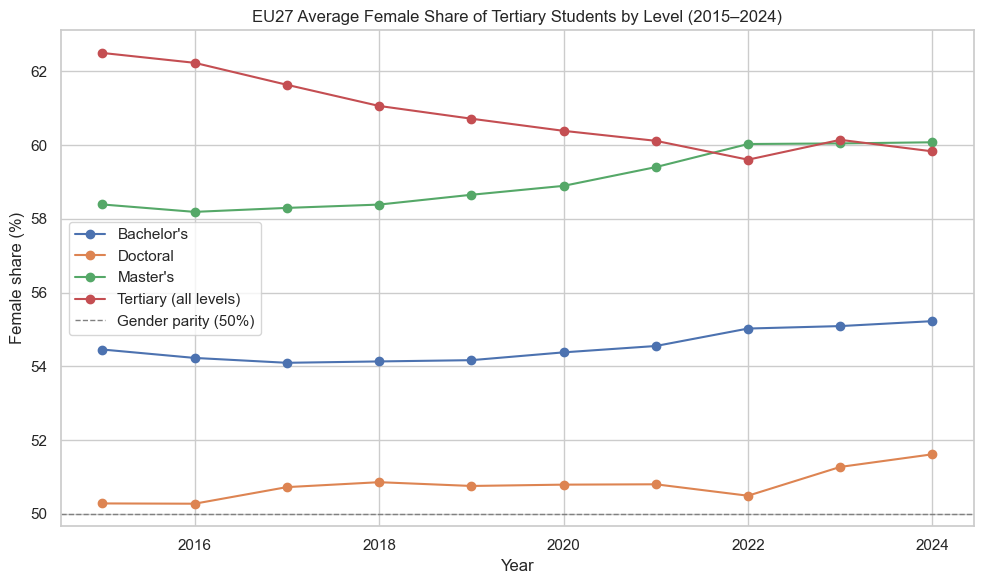

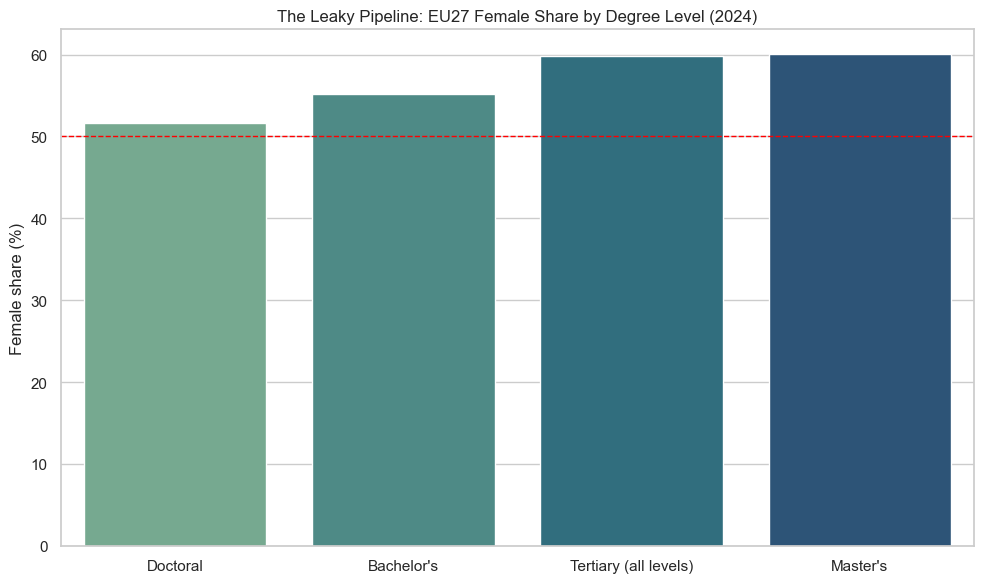

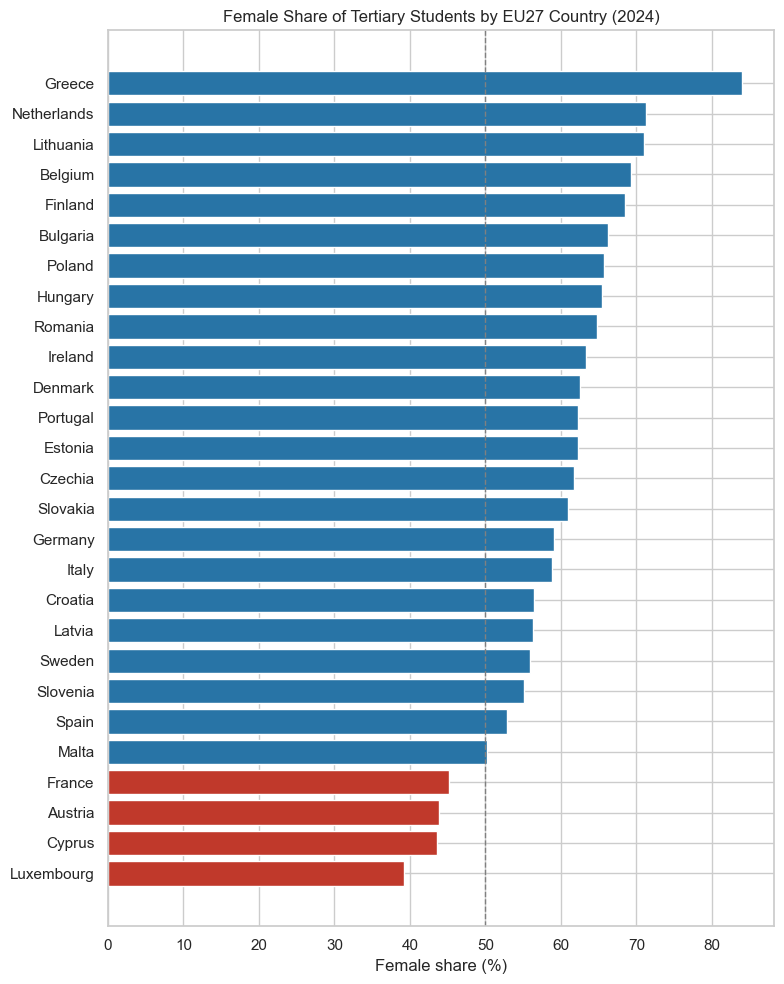


--- Highest / lowest female share countries (overall tertiary) ---
sex      Country  female_share
479       Greece     84.011605
798  Netherlands     71.277093
679    Lithuania     71.060311
sex     Country  female_share
39      Austria     43.809061
199      Cyprus     43.623141
719  Luxembourg     39.179818


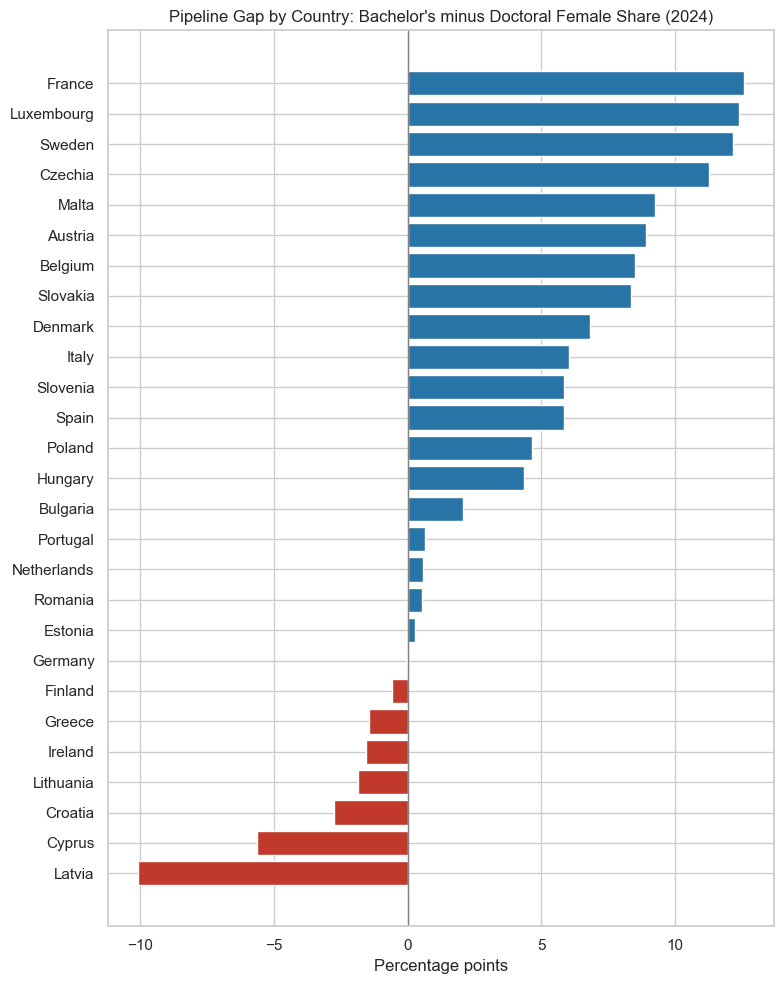

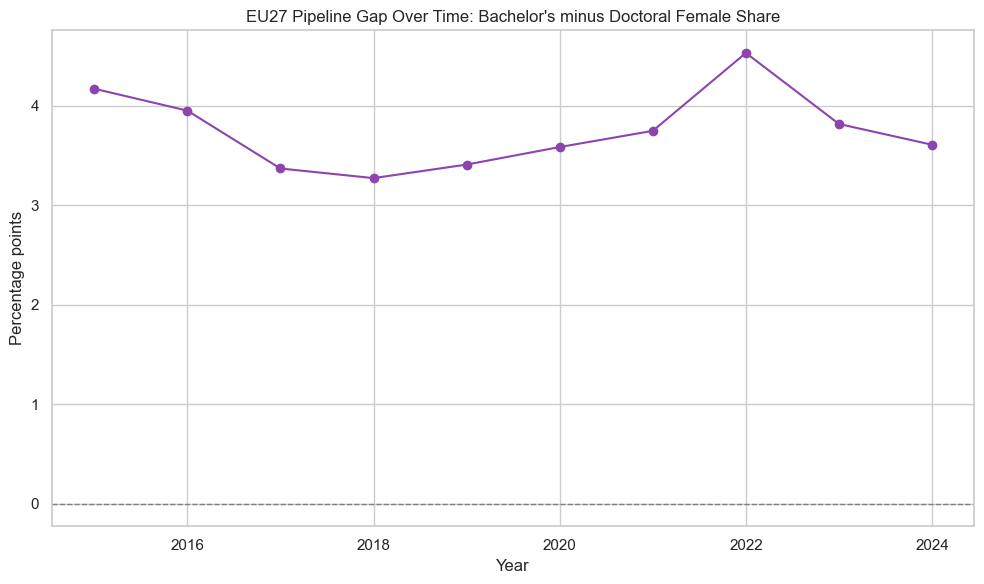

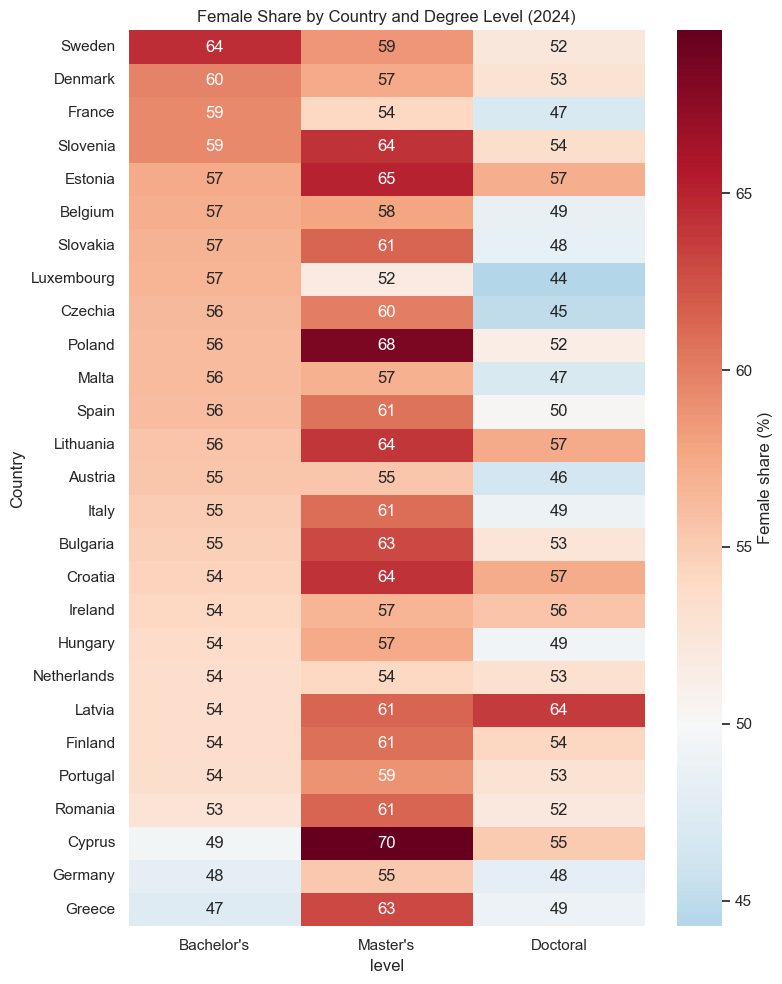


EU27 overall female share: 62.5% (2015) -> 59.8% (2024)
Highest female share country (2024): Greece (84.0%)
Lowest female share country (2024): Luxembourg (39.2%)
EU27 pipeline gap (2024): 3.6 pp


In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ------------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------------
# Change the path/filename to match your exported Eurostat file
FILE_PATH = "education_EU.xlsx"   # <-- edit this
df_raw = pd.read_excel(FILE_PATH)


# ------------------------------------------------------------------
# 2. EU27 COUNTRY LIST (edit if your "Country" column uses different labels,
#    e.g. ISO codes instead of full names)
# ------------------------------------------------------------------
EU27 = [
    "Belgium", "Bulgaria", "Czechia", "Denmark", "Germany", "Estonia",
    "Ireland", "Greece", "Spain", "France", "Croatia", "Italy", "Cyprus",
    "Latvia", "Lithuania", "Luxembourg", "Hungary", "Malta", "Netherlands",
    "Austria", "Poland", "Portugal", "Romania", "Slovenia", "Slovakia",
    "Finland", "Sweden",
]

df_raw = df_raw[df_raw["Country"].isin(EU27)].copy()

# ------------------------------------------------------------------
# 3. CLEAN MISSING-VALUE CODES
#    Eurostat commonly uses ":" or ": " for missing/confidential data
# ------------------------------------------------------------------
value_cols = [c for c in df_raw.columns if c != "Country"]
for c in value_cols:
    df_raw[c] = (
        df_raw[c]
        .astype(str)
        .str.replace(",", "", regex=False)   # remove thousand separators, if any
        .str.strip()
        .replace({":": np.nan, "": np.nan, "nan": np.nan})
    )
    df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

# ------------------------------------------------------------------
# 4. RESHAPE WIDE -> LONG
#    Column pattern: "{year}_{education level}_{sex}"
#    e.g. "2019_Bachelor's or equivalent level_Female"
# ------------------------------------------------------------------
df_long = df_raw.melt(id_vars="Country", value_vars=value_cols,
                       var_name="raw_col", value_name="students")

pattern = re.compile(r"^(\d{4})_(.+)_(Tot|Male|Female)$")

def parse_col(raw_col):
    m = pattern.match(raw_col)
    if not m:
        return pd.Series([np.nan, np.nan, np.nan])
    year, level, sex = m.groups()
    return pd.Series([int(year), level.strip(), sex])

df_long[["year", "level", "sex"]] = df_long["raw_col"].apply(parse_col)
df_long = df_long.drop(columns="raw_col").dropna(subset=["year"])
df_long["year"] = df_long["year"].astype(int)

# Shorten level labels for readability
level_map = {
    "Tertiary education (levels 5-8)": "Tertiary (all levels)",
    "Bachelor's or equivalent level": "Bachelor's",
    "Master's or equivalent level": "Master's",
    "Doctoral or equivalent level": "Doctoral",
}
df_long["level"] = df_long["level"].map(level_map).fillna(df_long["level"])

# ------------------------------------------------------------------
# 5. PIVOT TO GET Male/Female/Tot SIDE BY SIDE, COMPUTE FEMALE SHARE
# ------------------------------------------------------------------
df_wide_sex = df_long.pivot_table(
    index=["Country", "year", "level"], columns="sex", values="students"
).reset_index()

df_wide_sex["female_share"] = df_wide_sex["Female"] / df_wide_sex["Tot"] * 100
df_wide_sex["male_share"] = df_wide_sex["Male"] / df_wide_sex["Tot"] * 100

LATEST_YEAR = df_wide_sex["year"].max()
print(f"Latest year in dataset: {LATEST_YEAR}")

# ------------------------------------------------------------------
# 6. EU27 AVERAGE FEMALE SHARE OVER TIME, BY LEVEL
# ------------------------------------------------------------------
eu27_trend = (
    df_wide_sex.groupby(["year", "level"])["female_share"]
    .mean()
    .reset_index()
)

print("\n--- EU27 average female share by level, latest year ---")
print(eu27_trend[eu27_trend["year"] == LATEST_YEAR])

# CHART 1: Trend of female share over time, one line per level
plt.figure()
for lvl, sub in eu27_trend.groupby("level"):
    plt.plot(sub["year"], sub["female_share"], marker="o", label=lvl)
plt.axhline(50, color="grey", linestyle="--", linewidth=1, label="Gender parity (50%)")
plt.title("EU27 Average Female Share of Tertiary Students by Level (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Female share (%)")
plt.legend()
plt.tight_layout()
plt.savefig("chart1_female_share_trend.png", dpi=200)
plt.show()

# ------------------------------------------------------------------
# 7. "LEAKY PIPELINE": FEMALE SHARE BY LEVEL, LATEST YEAR, EU27 AVERAGE
# ------------------------------------------------------------------
pipeline_latest = eu27_trend[eu27_trend["year"] == LATEST_YEAR].sort_values("female_share")

plt.figure()
sns.barplot(data=pipeline_latest, x="level", y="female_share", palette="crest")
plt.axhline(50, color="red", linestyle="--", linewidth=1)
plt.title(f"The Leaky Pipeline: EU27 Female Share by Degree Level ({LATEST_YEAR})")
plt.xlabel("")
plt.ylabel("Female share (%)")
plt.tight_layout()
plt.savefig("chart2_pipeline_by_level.png", dpi=200)
plt.show()

# ------------------------------------------------------------------
# 8. FEMALE SHARE BY COUNTRY, LATEST YEAR, OVERALL TERTIARY LEVEL
# ------------------------------------------------------------------
country_latest = df_wide_sex[
    (df_wide_sex["year"] == LATEST_YEAR) & (df_wide_sex["level"] == "Tertiary (all levels)")
].sort_values("female_share", ascending=False)

plt.figure(figsize=(8, 10))
colors = ["#c0392b" if v < 50 else "#2874a6" for v in country_latest["female_share"]]
plt.barh(country_latest["Country"], country_latest["female_share"], color=colors)
plt.axvline(50, color="grey", linestyle="--", linewidth=1)
plt.gca().invert_yaxis()
plt.title(f"Female Share of Tertiary Students by EU27 Country ({LATEST_YEAR})")
plt.xlabel("Female share (%)")
plt.tight_layout()
plt.savefig("chart3_female_share_by_country.png", dpi=200)
plt.show()

print("\n--- Highest / lowest female share countries (overall tertiary) ---")
print(country_latest[["Country", "female_share"]].head(3))
print(country_latest[["Country", "female_share"]].tail(3))

# ------------------------------------------------------------------
# 9. PIPELINE GAP BY COUNTRY: Bachelor's female share - Doctoral female share
#    (higher value = stronger "leak" between undergrad and PhD level)
# ------------------------------------------------------------------
bach = df_wide_sex[(df_wide_sex["year"] == LATEST_YEAR) & (df_wide_sex["level"] == "Bachelor's")]
doc = df_wide_sex[(df_wide_sex["year"] == LATEST_YEAR) & (df_wide_sex["level"] == "Doctoral")]

gap_df = bach.merge(doc, on="Country", suffixes=("_bach", "_doc"))
gap_df["pipeline_gap"] = gap_df["female_share_bach"] - gap_df["female_share_doc"]
gap_df = gap_df.sort_values("pipeline_gap", ascending=False)

plt.figure(figsize=(8, 10))
colors = ["#c0392b" if v < 0 else "#2874a6" for v in gap_df["pipeline_gap"]]
plt.barh(gap_df["Country"], gap_df["pipeline_gap"], color=colors)
plt.axvline(0, color="grey", linewidth=1)
plt.gca().invert_yaxis()
plt.title(f"Pipeline Gap by Country: Bachelor's minus Doctoral Female Share ({LATEST_YEAR})")
plt.xlabel("Percentage points")
plt.tight_layout()
plt.savefig("chart4_pipeline_gap_by_country.png", dpi=200)
plt.show()

# ------------------------------------------------------------------
# 10. EU27 PIPELINE GAP TREND OVER TIME (2015-2024)
# ------------------------------------------------------------------
pipeline_trend = eu27_trend.pivot(index="year", columns="level", values="female_share")
pipeline_trend["pipeline_gap"] = pipeline_trend["Bachelor's"] - pipeline_trend["Doctoral"]

plt.figure()
plt.plot(pipeline_trend.index, pipeline_trend["pipeline_gap"], marker="o", color="#8e44ad")
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.title("EU27 Pipeline Gap Over Time: Bachelor's minus Doctoral Female Share")
plt.xlabel("Year")
plt.ylabel("Percentage points")
plt.tight_layout()
plt.savefig("chart5_pipeline_gap_trend.png", dpi=200)
plt.show()

# ------------------------------------------------------------------
# 11. HEATMAP: Female share by country (rows) x level (columns), latest year
# ------------------------------------------------------------------
heat_df = df_wide_sex[df_wide_sex["year"] == LATEST_YEAR].pivot(
    index="Country", columns="level", values="female_share"
)
heat_df = heat_df[["Bachelor's", "Master's", "Doctoral"]].sort_values("Bachelor's", ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(heat_df, annot=True, fmt=".0f", cmap="RdBu_r", center=50, cbar_kws={"label": "Female share (%)"})
plt.title(f"Female Share by Country and Degree Level ({LATEST_YEAR})")
plt.tight_layout()
plt.savefig("chart6_heatmap_country_level.png", dpi=200)
plt.show()

# ------------------------------------------------------------------
# 12. SUMMARY STATS TO QUOTE IN THE "INSIGHTS" SLIDE
# ------------------------------------------------------------------
overall_2015 = eu27_trend[(eu27_trend["year"] == eu27_trend["year"].min()) &
                           (eu27_trend["level"] == "Tertiary (all levels)")]["female_share"].values[0]
overall_latest = eu27_trend[(eu27_trend["year"] == LATEST_YEAR) &
                             (eu27_trend["level"] == "Tertiary (all levels)")]["female_share"].values[0]

print(f"\nEU27 overall female share: {overall_2015:.1f}% (2015) -> {overall_latest:.1f}% ({LATEST_YEAR})")
print(f"Highest female share country ({LATEST_YEAR}): "
      f"{country_latest.iloc[0]['Country']} ({country_latest.iloc[0]['female_share']:.1f}%)")
print(f"Lowest female share country ({LATEST_YEAR}): "
      f"{country_latest.iloc[-1]['Country']} ({country_latest.iloc[-1]['female_share']:.1f}%)")
print(f"EU27 pipeline gap ({LATEST_YEAR}): {pipeline_trend['pipeline_gap'].iloc[-1]:.1f} pp")

In [8]:
import plotly.express as px

# ------------------------------------------------------------------
# MAP: Female share of tertiary students by EU27 country (latest year)
# Reuses `country_latest` and `LATEST_YEAR` from the previous cell
# ------------------------------------------------------------------
ISO3 = {
    "Belgium": "BEL", "Bulgaria": "BGR", "Czechia": "CZE", "Denmark": "DNK",
    "Germany": "DEU", "Estonia": "EST", "Ireland": "IRL", "Greece": "GRC",
    "Spain": "ESP", "France": "FRA", "Croatia": "HRV", "Italy": "ITA",
    "Cyprus": "CYP", "Latvia": "LVA", "Lithuania": "LTU", "Luxembourg": "LUX",
    "Hungary": "HUN", "Malta": "MLT", "Netherlands": "NLD", "Austria": "AUT",
    "Poland": "POL", "Portugal": "PRT", "Romania": "ROU", "Slovenia": "SVN",
    "Slovakia": "SVK", "Finland": "FIN", "Sweden": "SWE",
}

map_df = country_latest.copy()
map_df["iso3"] = map_df["Country"].map(ISO3)

missing = map_df[map_df["iso3"].isna()]
if len(missing):
    print("Warning: countries with no ISO3 match (map will drop these):")
    print(missing["Country"].tolist())

fig = px.choropleth(
    map_df,
    locations="iso3",
    color="female_share",
    hover_name="Country",
    hover_data={"iso3": False, "female_share": ":.1f"},
    scope="europe",
    color_continuous_scale="RdBu",
    range_color=(35, 75),
    color_continuous_midpoint=50,
    labels={"female_share": "Female share (%)"},
    title=f"Female Share of Tertiary Students by EU27 Country ({LATEST_YEAR})",
)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin=dict(l=0, r=0, t=60, b=0), width=900, height=700)
fig.show()

# Static export for the slide deck (requires: pip install -U kaleido)
fig.write_image("chart7_map_female_share.png", scale=2)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


Sheets found:
- Data: (39, 121), matching columns = 120

Using sheet: Data

Loaded file: Education_EU.xlsx
Rows: 39 | Columns: 121

Countries after EU27 filter: 27 rows out of 39
['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

Long format created.
    Country   students  year                  level  sex
0   Belgium   504745.0  2015  Tertiary (all levels)  Tot
1  Bulgaria   278953.0  2015  Tertiary (all levels)  Tot
2   Czechia   395529.0  2015  Tertiary (all levels)  Tot
3   Denmark   313756.0  2015  Tertiary (all levels)  Tot
4   Germany  2977781.0  2015  Tertiary (all levels)  Tot

Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.in

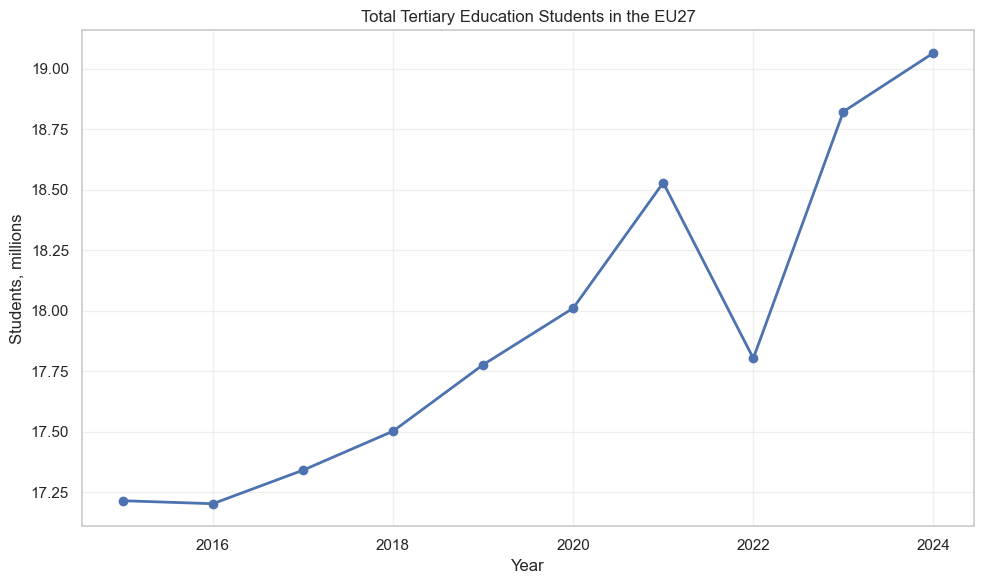


--- ANALYSIS 1: TOTAL EU27 TREND ---
EU27 tertiary students: 17.22M (2015) -> 19.07M (2024)
Overall change: 10.7%


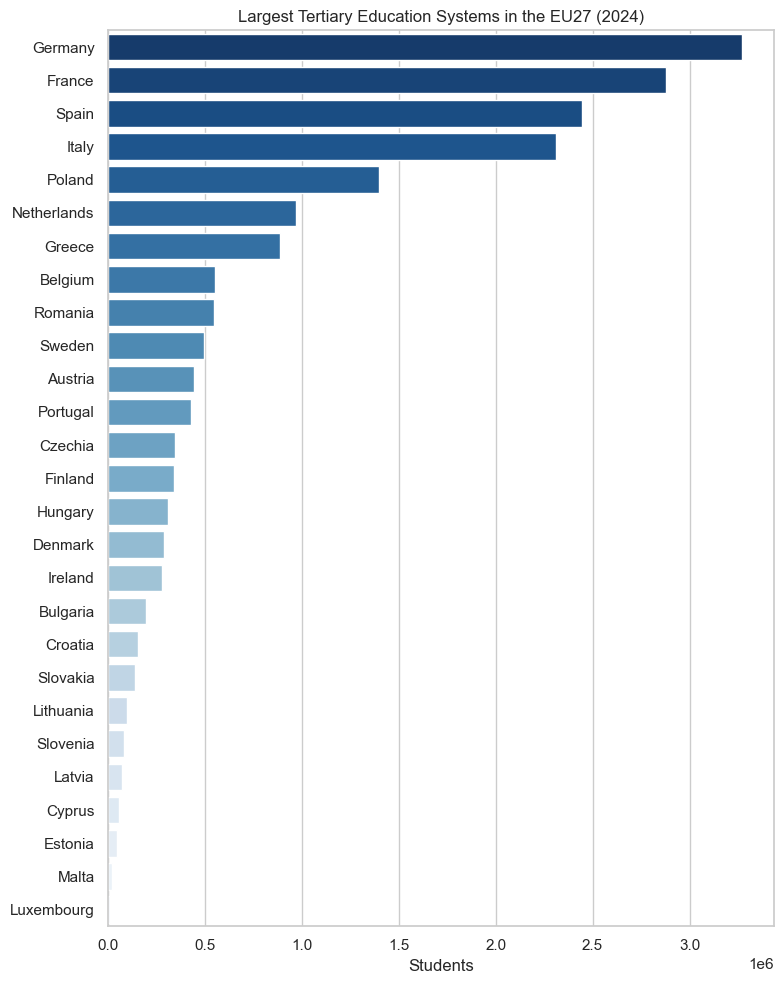


--- ANALYSIS 2: LARGEST UNIVERSITY SYSTEMS ---
    Country       Tot
    Germany 3272087.0
     France 2879212.0
      Spain 2444285.0
      Italy 2311826.0
     Poland 1397522.0
Netherlands  969491.0
     Greece  885486.0
    Belgium  551141.0
    Romania  544623.0
     Sweden  494296.0


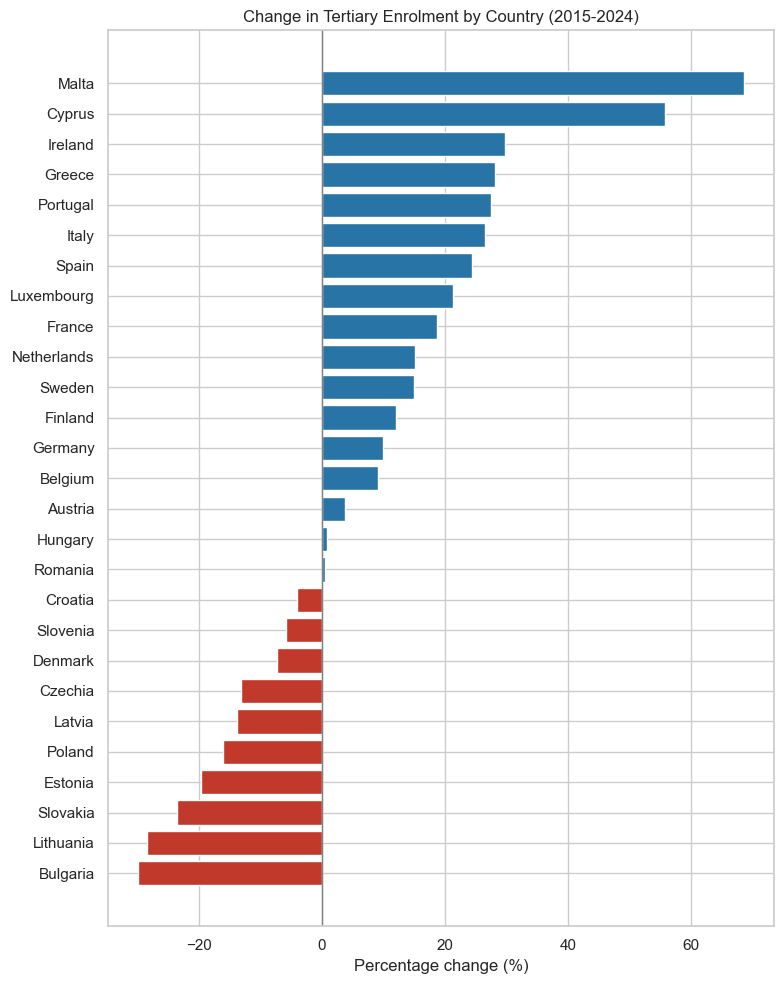


--- ANALYSIS 3: COUNTRY GROWTH ---

Fastest growing countries:
 Country  students_start  students_end  absolute_change  percentage_change
   Malta         13216.0       22276.0           9060.0          68.553269
  Cyprus         37166.0       57889.0          20723.0          55.757951
 Ireland        214632.0      278366.0          63734.0          29.694547
  Greece        690868.0      885486.0         194618.0          28.170070
Portugal        337507.0      430226.0          92719.0          27.471727

Weakest growth / decline:
  Country  students_start  students_end  absolute_change  percentage_change
 Bulgaria        278953.0      195697.0         -83256.0         -29.845888
Lithuania        140629.0      100744.0         -39885.0         -28.361860
 Slovakia        184390.0      141119.0         -43271.0         -23.467108
  Estonia         55214.0       44377.0         -10837.0         -19.627268
   Poland       1665305.0     1397522.0        -267783.0         -16.080117


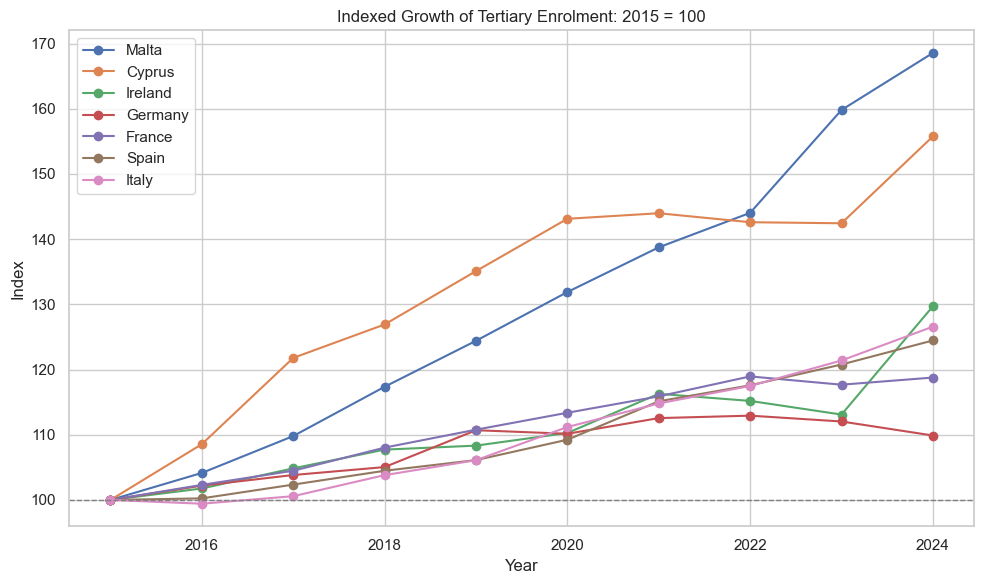

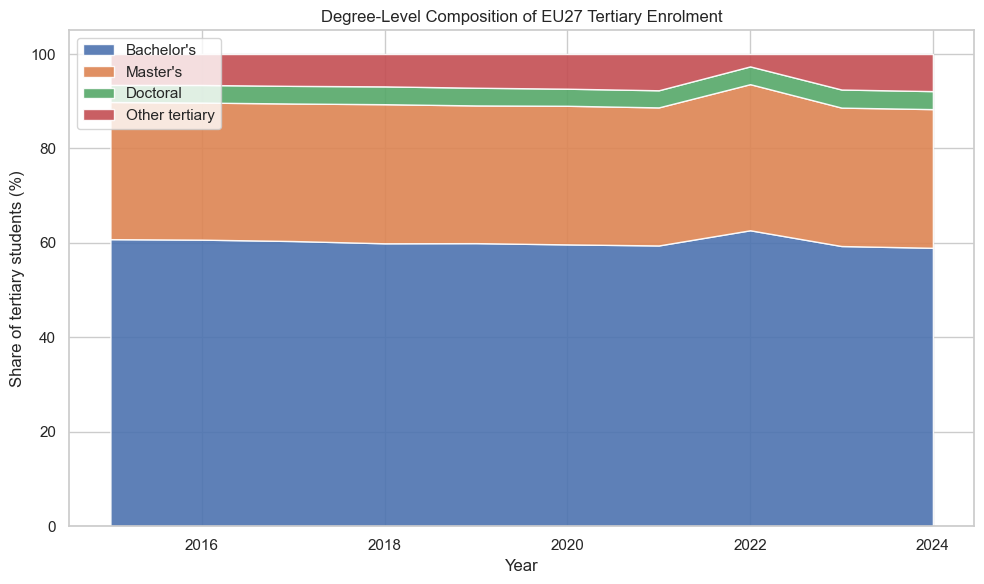


--- ANALYSIS 5: DEGREE-LEVEL COMPOSITION, LATEST YEAR ---
level
Bachelor's        58.969445
Master's          29.365624
Other tertiary     7.853198
Doctoral           3.811733


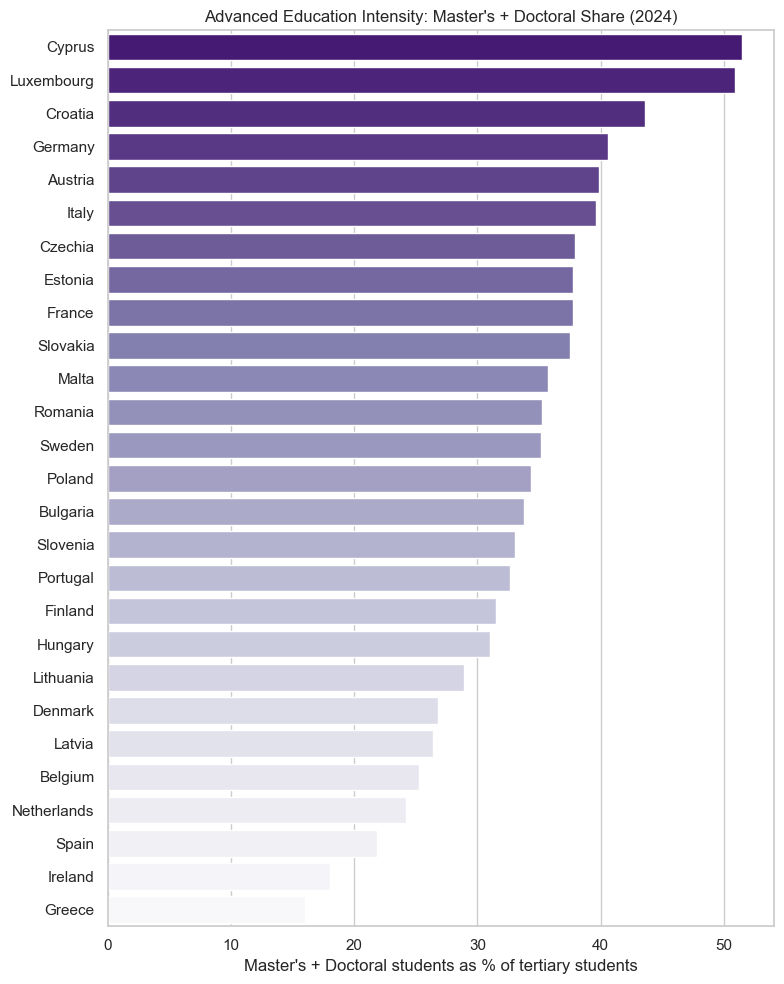


--- ANALYSIS 6: ADVANCED EDUCATION INTENSITY ---

Highest advanced education intensity:
   Country  advanced_share
    Cyprus       51.500285
Luxembourg       50.908656
   Croatia       43.587945
   Germany       40.601396
   Austria       39.843748

Lowest advanced education intensity:
    Country  advanced_share
    Belgium       25.217866
Netherlands       24.194861
      Spain       21.814968
    Ireland       18.019083
     Greece       15.988395


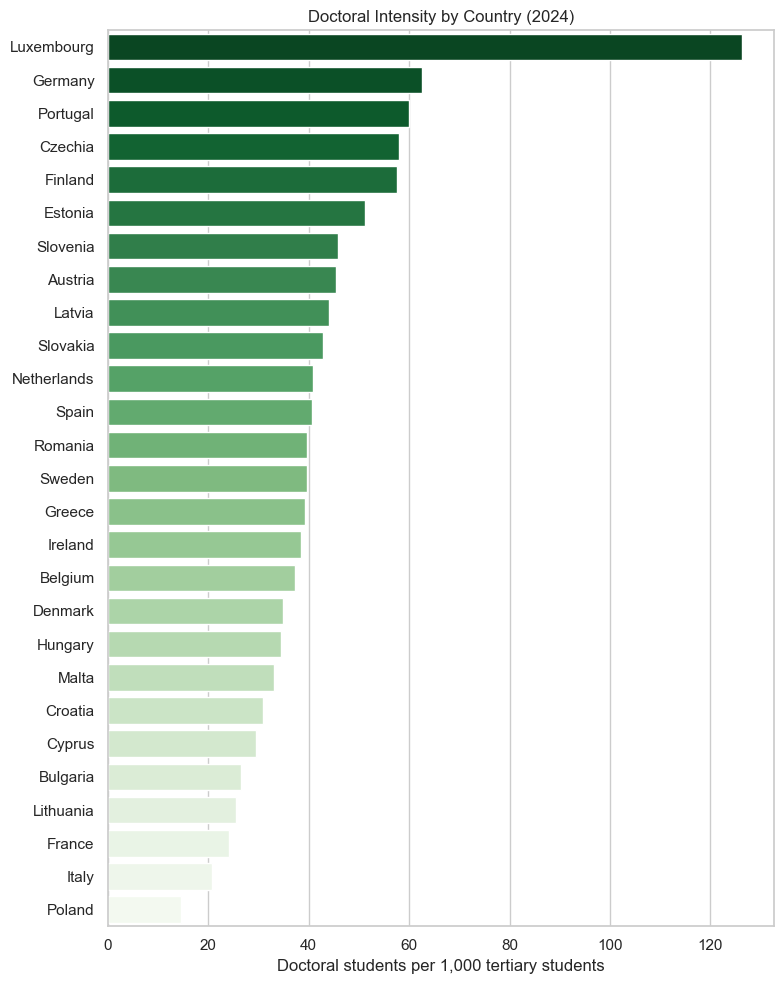


--- ANALYSIS 7: DOCTORAL INTENSITY ---

Highest doctoral intensity:
   Country  doctoral_per_1000
Luxembourg         126.374940
   Germany          62.634337
  Portugal          59.894102
   Czechia          58.055359
   Finland          57.584236

Lowest doctoral intensity:
  Country  doctoral_per_1000
 Bulgaria          26.489931
Lithuania          25.500278
   France          24.186826
    Italy          20.745073
   Poland          14.620879


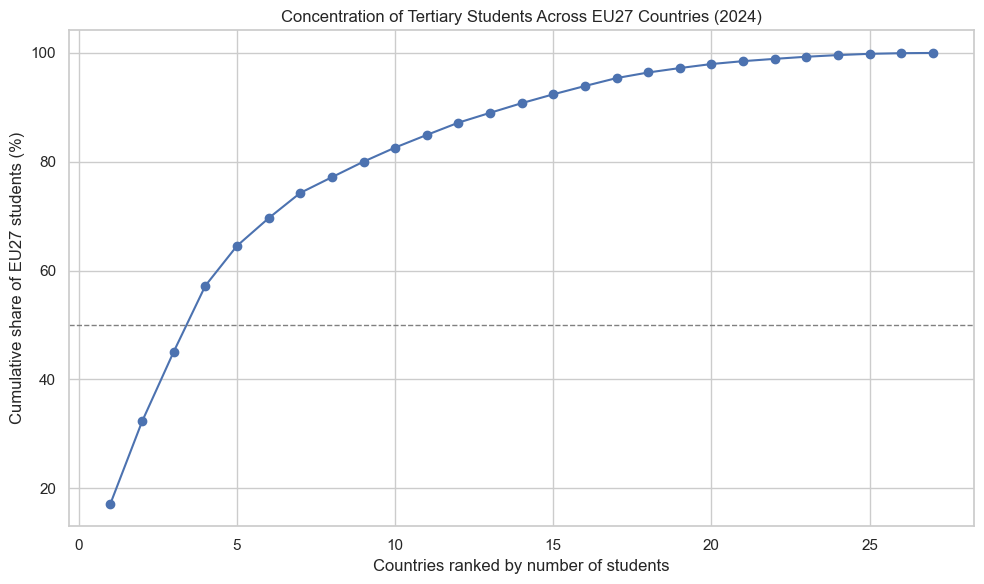


--- ANALYSIS 8: CONCENTRATION ---
Top 5 countries account for 64.5% of EU27 tertiary students.
Top 10 countries account for 82.6% of EU27 tertiary students.


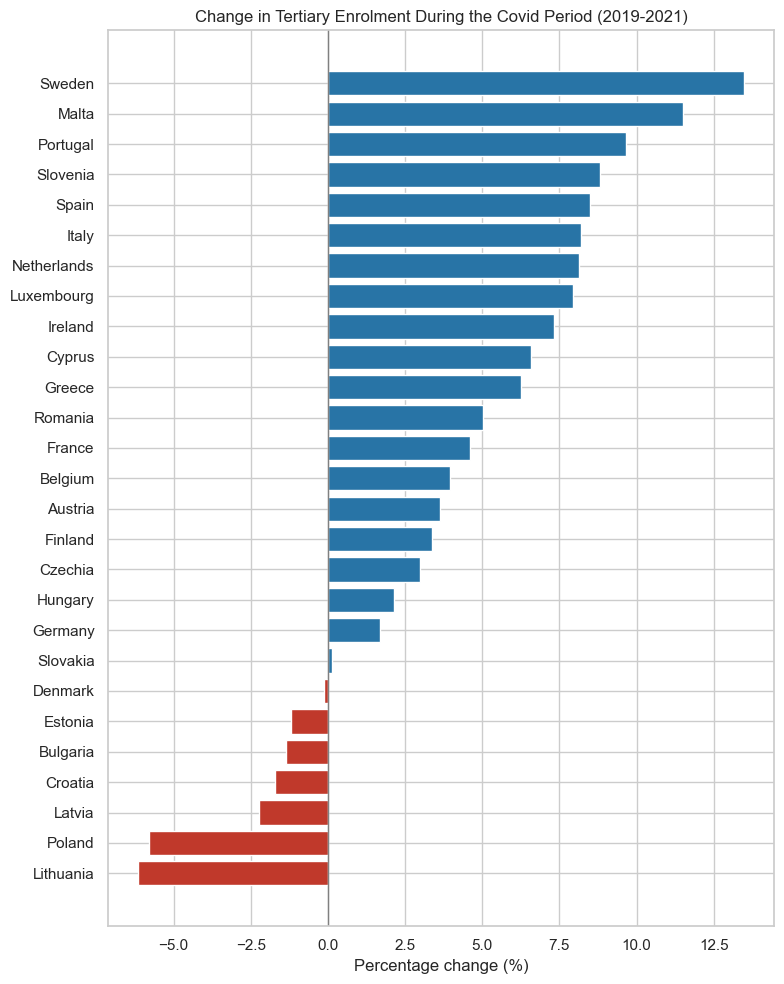


--- ANALYSIS 9: COVID PERIOD CHECK ---

Largest increases during 2019-2021:
 Country  students_2019  students_2021  change_2019_2021
  Sweden       432233.0       490470.0         13.473520
   Malta        16442.0        18336.0         11.519280
Portugal       368181.0       403746.0          9.659651
Slovenia        75991.0        82694.0          8.820781
   Spain      2083979.0      2261063.0          8.497398

Largest decreases during 2019-2021:
  Country  students_2019  students_2021  change_2019_2021
Lithuania       111768.0       104897.0         -6.147556
   Poland      1430981.0      1347799.0         -5.812935
   Latvia        80355.0        78548.0         -2.248771
  Croatia       163867.0       161077.0         -1.702600
 Bulgaria       229464.0       226361.0         -1.352282


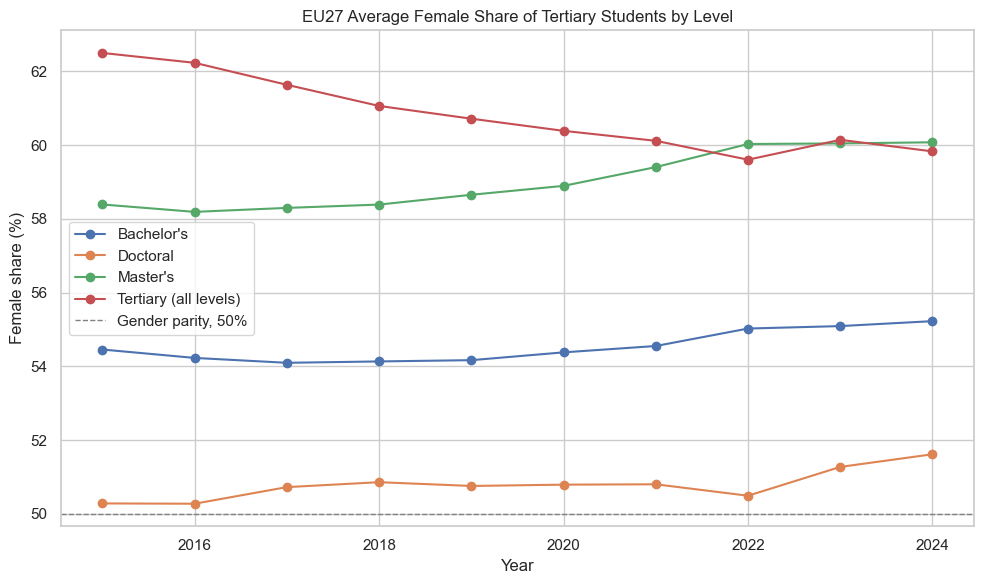

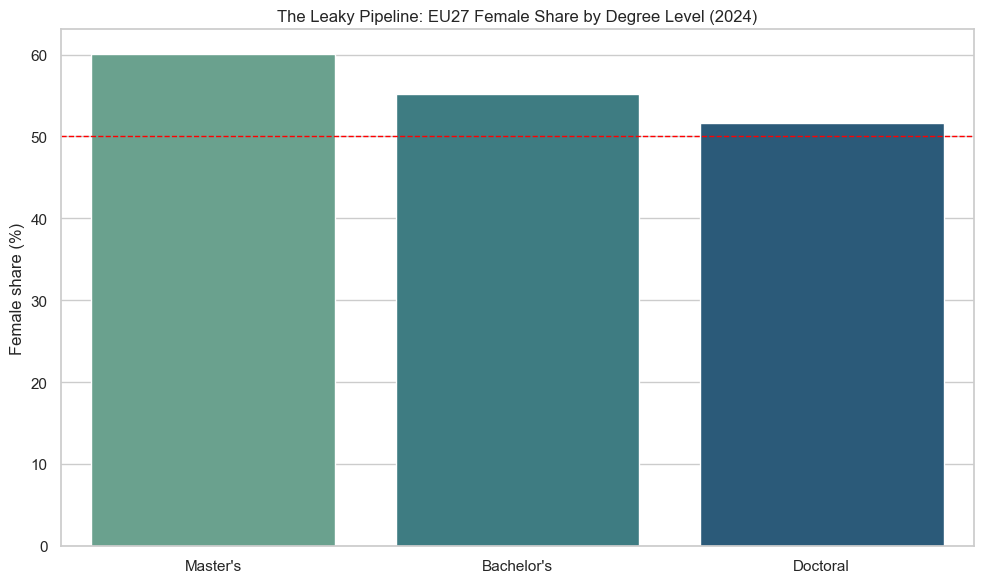

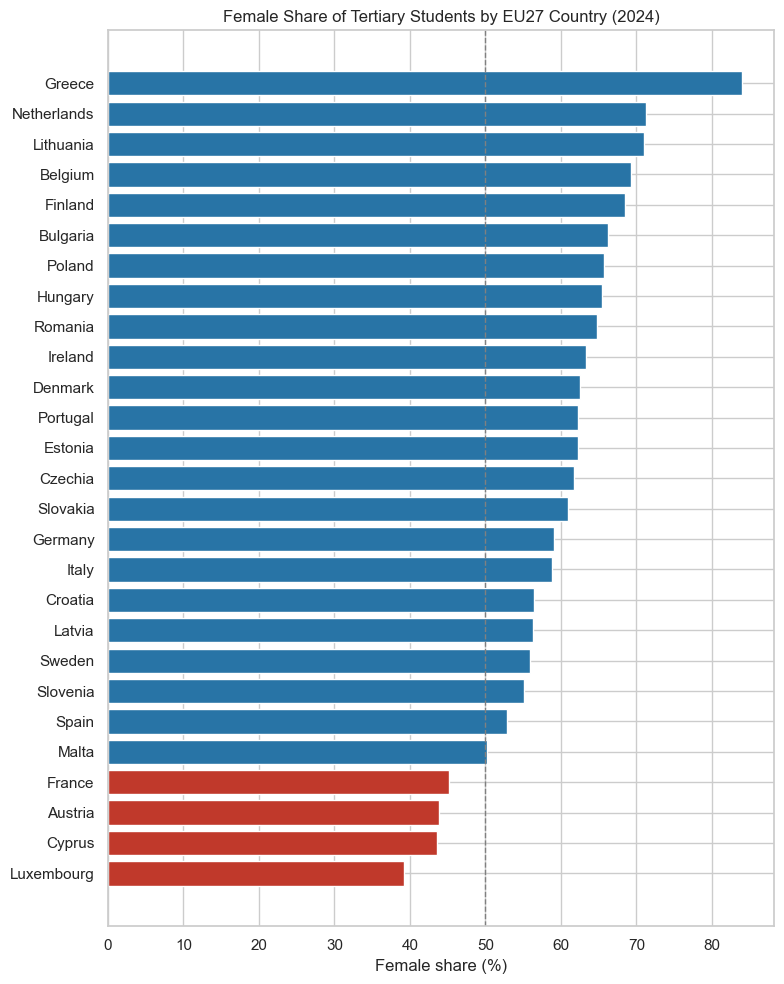

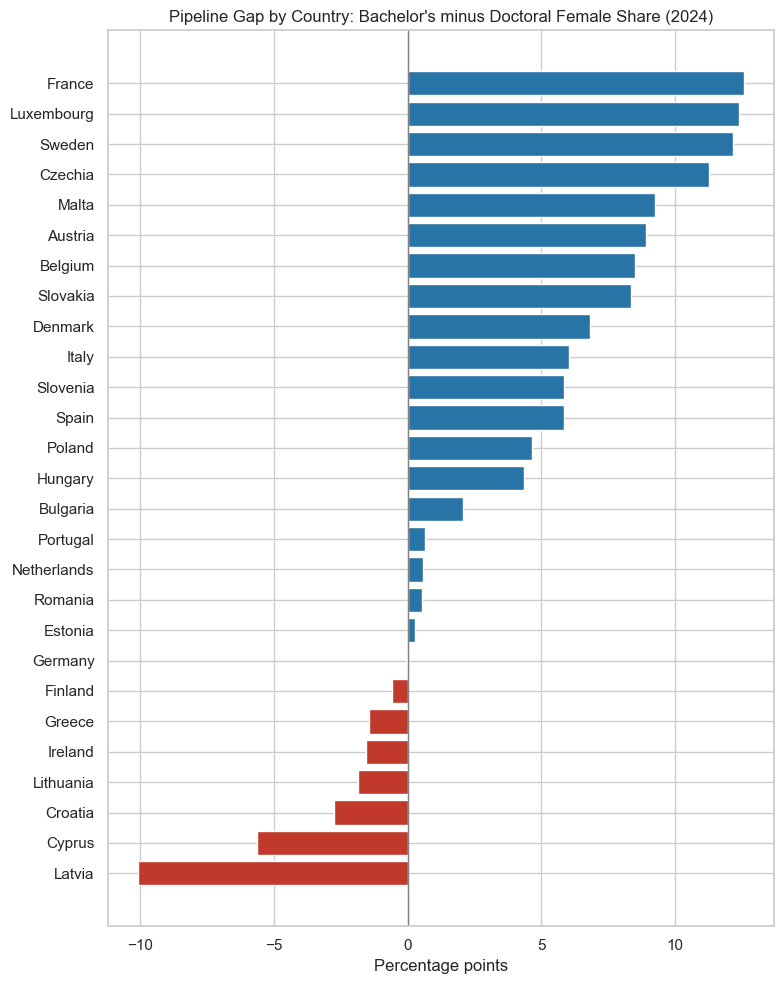

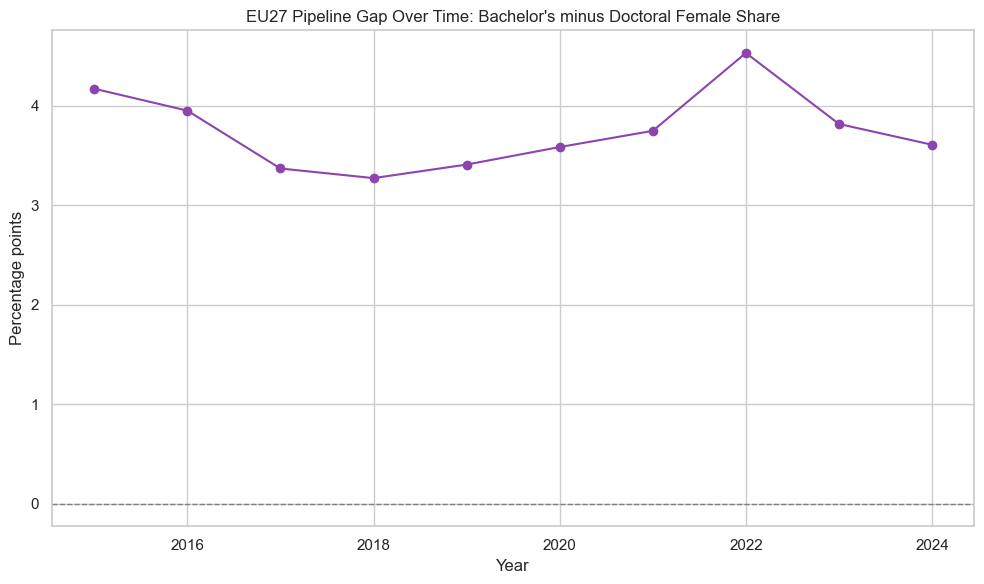

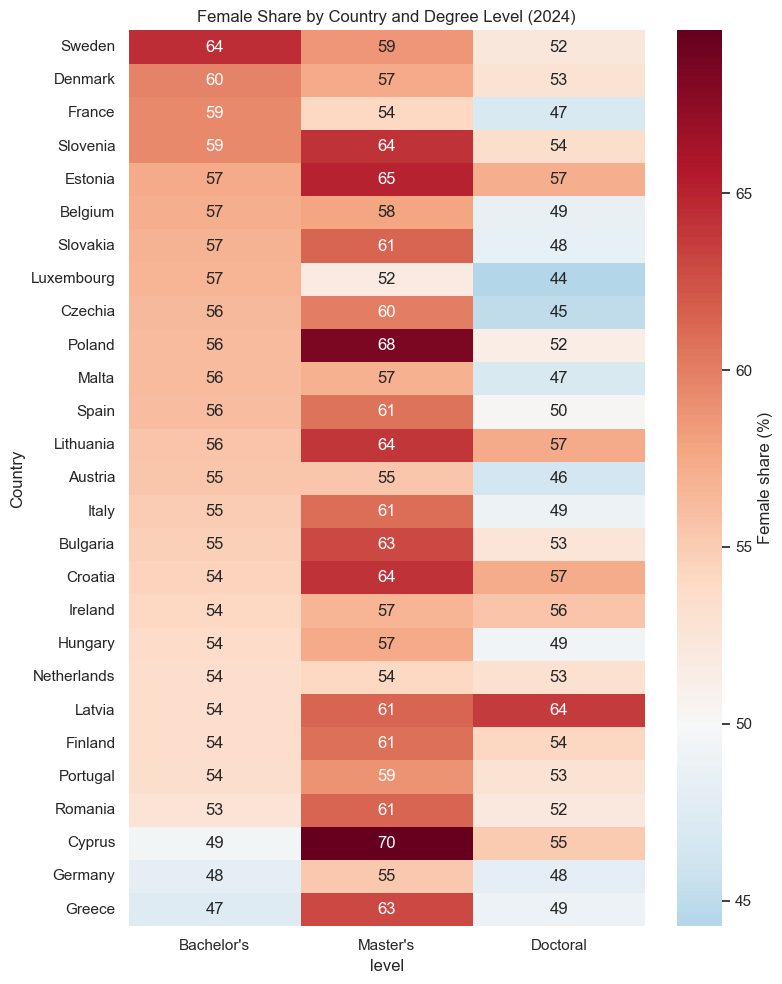


--- ANALYSIS 10: GENDER BALANCE ---
EU27 average female share: 62.5% (2015) -> 59.8% (2024)
Countries with female majority in tertiary education: 23 out of 27

Highest female share countries:
    Country  female_share
     Greece     84.011605
Netherlands     71.277093
  Lithuania     71.060311
    Belgium     69.289166
    Finland     68.490413

Lowest female share countries:
   Country  female_share
     Malta     50.210989
    France     45.195734
   Austria     43.809061
    Cyprus     43.623141
Luxembourg     39.179818

Largest pipeline gaps, Bachelor's female share minus Doctoral female share:
   Country  female_share_bach  female_share_doc  pipeline_gap
    France          59.485307         46.899008     12.586299
Luxembourg          56.698200         44.276254     12.421946
    Sweden          64.448781         52.275046     12.173735
   Czechia          56.399002         45.102951     11.296051
     Malta          56.155565         46.875000      9.280565

Plotly interactive 

In [9]:
# ============================================================
# EUROSTAT EDUCATION EU - FULL ANALYSIS IN ONE CELL
# Dataset: educ_uoe_enrt03
# Topic: Tertiary education enrolment by country, sex and level
# ============================================================

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ============================================================
# 0. SETTINGS
# ============================================================

FILE_PATH = "Education_EU.xlsx"   # <-- cambia qui se il tuo file ha un altro nome
OUTPUT_DIR = Path("education_viz_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# 1. LOAD DATA - ROBUST EXCEL / CSV LOADING
# ============================================================

def normalize_col(c):
    c = str(c)
    c = c.replace("\n", " ")
    c = c.replace("\r", " ")
    c = c.replace("\xa0", " ")
    c = re.sub(r"\s+", " ", c)
    return c.strip()

def count_matching_columns(columns):
    count = 0
    pattern = re.compile(r"^(\d{4})_(.+)_(Tot|Male|Female)$")
    for c in columns:
        if pattern.match(normalize_col(c)):
            count += 1
    return count

path = Path(FILE_PATH)

if not path.exists():
    possible_files = list(Path(".").glob("*.xlsx")) + list(Path(".").glob("*.xls")) + list(Path(".").glob("*.csv"))
    if not possible_files:
        raise FileNotFoundError("No Excel/CSV file found. Upload your Eurostat file and update FILE_PATH.")
    path = possible_files[0]
    print(f"FILE_PATH not found. Automatically using: {path}")

if path.suffix.lower() in [".xlsx", ".xls"]:
    sheets = pd.read_excel(path, sheet_name=None)

    print("Sheets found:")
    for sheet_name, sheet_df in sheets.items():
        print(f"- {sheet_name}: {sheet_df.shape}, matching columns = {count_matching_columns(sheet_df.columns)}")

    best_sheet_name = max(sheets.keys(), key=lambda s: count_matching_columns(sheets[s].columns))
    df_raw = sheets[best_sheet_name].copy()
    print(f"\nUsing sheet: {best_sheet_name}")

else:
    df_raw = pd.read_csv(path, sep=None, engine="python")

df_raw.columns = [normalize_col(c) for c in df_raw.columns]

print("\nLoaded file:", path)
print("Rows:", df_raw.shape[0], "| Columns:", df_raw.shape[1])

# Find country column
country_col = None
for c in df_raw.columns:
    if c.lower() in ["country", "geo", "geo/time", "location"]:
        country_col = c
        break

if country_col is None:
    country_col = df_raw.columns[0]

df_raw = df_raw.rename(columns={country_col: "Country"})
df_raw["Country"] = df_raw["Country"].astype(str).str.strip()

# ============================================================
# 2. FILTER EU27 COUNTRIES
# ============================================================

EU27 = [
    "Belgium", "Bulgaria", "Czechia", "Denmark", "Germany", "Estonia",
    "Ireland", "Greece", "Spain", "France", "Croatia", "Italy", "Cyprus",
    "Latvia", "Lithuania", "Luxembourg", "Hungary", "Malta", "Netherlands",
    "Austria", "Poland", "Portugal", "Romania", "Slovenia", "Slovakia",
    "Finland", "Sweden",
]

code_map = {
    "AT": "Austria", "BE": "Belgium", "BG": "Bulgaria", "HR": "Croatia",
    "CY": "Cyprus", "CZ": "Czechia", "DK": "Denmark", "EE": "Estonia",
    "FI": "Finland", "FR": "France", "DE": "Germany", "EL": "Greece",
    "GR": "Greece", "HU": "Hungary", "IE": "Ireland", "IT": "Italy",
    "LV": "Latvia", "LT": "Lithuania", "LU": "Luxembourg", "MT": "Malta",
    "NL": "Netherlands", "PL": "Poland", "PT": "Portugal", "RO": "Romania",
    "SK": "Slovakia", "SI": "Slovenia", "ES": "Spain", "SE": "Sweden"
}

df_raw["Country"] = df_raw["Country"].replace(code_map)
df_raw["Country"] = df_raw["Country"].replace({"Czech Republic": "Czechia"})

before_filter = df_raw.shape[0]
df_raw = df_raw[df_raw["Country"].isin(EU27)].copy()
after_filter = df_raw.shape[0]

print(f"\nCountries after EU27 filter: {after_filter} rows out of {before_filter}")
print(sorted(df_raw["Country"].unique()))

# ============================================================
# 3. CLEAN NUMERIC VALUES
# ============================================================

value_cols = [c for c in df_raw.columns if c != "Country"]

def clean_number(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", ":", ": ", "nan", "NaN", "None"]:
        return np.nan

    # Remove Eurostat flags such as b, p, e
    s = re.sub(r"[A-Za-z]", "", s)
    s = s.replace(" ", "")

    # Manage separators
    if "," in s and "." not in s:
        s = s.replace(",", ".")
    else:
        s = s.replace(",", "")

    return pd.to_numeric(s, errors="coerce")

for c in value_cols:
    df_raw[c] = df_raw[c].apply(clean_number)

# ============================================================
# 4. RESHAPE WIDE TO LONG
# Column pattern: 2024_Bachelor's or equivalent level_Female
# ============================================================

df_long = df_raw.melt(
    id_vars="Country",
    value_vars=value_cols,
    var_name="raw_col",
    value_name="students"
)

pattern = re.compile(r"^(\d{4})_(.+)_(Tot|Male|Female)$")

def parse_col(raw_col):
    raw_col = normalize_col(raw_col)
    m = pattern.match(raw_col)
    if not m:
        return pd.Series([np.nan, np.nan, np.nan])
    year, level, sex = m.groups()
    return pd.Series([int(year), level.strip(), sex.strip()])

df_long[["year", "level", "sex"]] = df_long["raw_col"].apply(parse_col)
df_long = df_long.drop(columns="raw_col")
df_long = df_long.dropna(subset=["year"])
df_long["year"] = df_long["year"].astype(int)
df_long = df_long.dropna(subset=["students"])

level_map = {
    "Tertiary education (levels 5-8)": "Tertiary (all levels)",
    "Bachelor's or equivalent level": "Bachelor's",
    "Master's or equivalent level": "Master's",
    "Doctoral or equivalent level": "Doctoral",
}

df_long["level"] = df_long["level"].map(level_map).fillna(df_long["level"])

print("\nLong format created.")
print(df_long.head())
print("\nYears:", sorted(df_long["year"].unique()))
print("Levels:", sorted(df_long["level"].unique()))
print("Sex categories:", sorted(df_long["sex"].unique()))
print("Countries:", df_long["Country"].nunique())

LATEST_YEAR = int(df_long["year"].max())
START_YEAR = int(df_long["year"].min())

print(f"\nAnalysis period: {START_YEAR}-{LATEST_YEAR}")

# ============================================================
# 5. PIVOT SEX CATEGORIES SIDE BY SIDE
# ============================================================

df_wide_sex = df_long.pivot_table(
    index=["Country", "year", "level"],
    columns="sex",
    values="students",
    aggfunc="sum"
).reset_index()

# Ensure all expected columns exist
for col in ["Tot", "Male", "Female"]:
    if col not in df_wide_sex.columns:
        df_wide_sex[col] = np.nan

# If Tot is missing but Male and Female exist, reconstruct Tot
df_wide_sex["Tot"] = df_wide_sex["Tot"].fillna(df_wide_sex["Male"] + df_wide_sex["Female"])

df_wide_sex["female_share"] = df_wide_sex["Female"] / df_wide_sex["Tot"] * 100
df_wide_sex["male_share"] = df_wide_sex["Male"] / df_wide_sex["Tot"] * 100
df_wide_sex["gender_gap_pp"] = df_wide_sex["female_share"] - 50

has_gender = df_wide_sex["Female"].notna().any() and df_wide_sex["Male"].notna().any()

if has_gender:
    print("\nGender data available: YES")
else:
    print("\nGender data available: NO. Gender-specific charts will be skipped.")

# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=250, bbox_inches="tight")
    plt.show()

def fmt_million(x):
    return f"{x / 1_000_000:.2f}M"

def fmt_number(x):
    return f"{x:,.0f}"

# ============================================================
# 7. ANALYSIS 1 - TOTAL EU27 TERTIARY ENROLMENT TREND
# ============================================================

total_trend = (
    df_wide_sex[df_wide_sex["level"] == "Tertiary (all levels)"]
    .groupby("year", as_index=False)["Tot"]
    .sum()
)

plt.figure()
plt.plot(total_trend["year"], total_trend["Tot"] / 1_000_000, marker="o", linewidth=2)
plt.title("Total Tertiary Education Students in the EU27")
plt.xlabel("Year")
plt.ylabel("Students, millions")
plt.grid(alpha=0.3)
save_chart("chart01_total_tertiary_students_trend.png")

total_start = total_trend.loc[total_trend["year"] == START_YEAR, "Tot"].iloc[0]
total_end = total_trend.loc[total_trend["year"] == LATEST_YEAR, "Tot"].iloc[0]
total_change_pct = (total_end - total_start) / total_start * 100

print("\n--- ANALYSIS 1: TOTAL EU27 TREND ---")
print(f"EU27 tertiary students: {fmt_million(total_start)} ({START_YEAR}) -> {fmt_million(total_end)} ({LATEST_YEAR})")
print(f"Overall change: {total_change_pct:.1f}%")

# ============================================================
# 8. ANALYSIS 2 - LARGEST UNIVERSITY SYSTEMS
# ============================================================

largest_systems = (
    df_wide_sex[
        (df_wide_sex["year"] == LATEST_YEAR) &
        (df_wide_sex["level"] == "Tertiary (all levels)")
    ][["Country", "Tot"]]
    .dropna()
    .sort_values("Tot", ascending=False)
)

plt.figure(figsize=(8, 10))
sns.barplot(data=largest_systems, y="Country", x="Tot", palette="Blues_r")
plt.title(f"Largest Tertiary Education Systems in the EU27 ({LATEST_YEAR})")
plt.xlabel("Students")
plt.ylabel("")
save_chart("chart02_largest_university_systems.png")

print("\n--- ANALYSIS 2: LARGEST UNIVERSITY SYSTEMS ---")
print(largest_systems.head(10).to_string(index=False))

# ============================================================
# 9. ANALYSIS 3 - COUNTRY GROWTH 2015-2024
# ============================================================

tertiary_country_year = df_wide_sex[
    df_wide_sex["level"] == "Tertiary (all levels)"
].pivot_table(
    index="Country",
    columns="year",
    values="Tot",
    aggfunc="sum"
)

growth_df = tertiary_country_year[[START_YEAR, LATEST_YEAR]].copy()
growth_df = growth_df.dropna()
growth_df.columns = ["students_start", "students_end"]
growth_df["absolute_change"] = growth_df["students_end"] - growth_df["students_start"]
growth_df["percentage_change"] = growth_df["absolute_change"] / growth_df["students_start"] * 100
growth_df = growth_df.reset_index()

growth_df_sorted = growth_df.sort_values("percentage_change", ascending=True)

plt.figure(figsize=(8, 10))
colors = ["#c0392b" if v < 0 else "#2874a6" for v in growth_df_sorted["percentage_change"]]
plt.barh(growth_df_sorted["Country"], growth_df_sorted["percentage_change"], color=colors)
plt.axvline(0, color="grey", linewidth=1)
plt.title(f"Change in Tertiary Enrolment by Country ({START_YEAR}-{LATEST_YEAR})")
plt.xlabel("Percentage change (%)")
plt.ylabel("")
save_chart("chart03_country_growth_percentage.png")

print("\n--- ANALYSIS 3: COUNTRY GROWTH ---")
print("\nFastest growing countries:")
print(growth_df.sort_values("percentage_change", ascending=False).head(5).to_string(index=False))

print("\nWeakest growth / decline:")
print(growth_df.sort_values("percentage_change", ascending=True).head(5).to_string(index=False))

# ============================================================
# 10. ANALYSIS 4 - INDEXED GROWTH, 2015 = 100
# ============================================================

indexed = tertiary_country_year.copy()
indexed = indexed.div(indexed[START_YEAR], axis=0) * 100

fastest = growth_df.sort_values("percentage_change", ascending=False)["Country"].head(3).tolist()
largest = largest_systems["Country"].head(3).tolist()
selected_countries = list(dict.fromkeys(fastest + largest + ["Italy"]))
selected_countries = [c for c in selected_countries if c in indexed.index]

plt.figure()
for country in selected_countries:
    plt.plot(indexed.columns, indexed.loc[country], marker="o", label=country)

plt.axhline(100, color="grey", linestyle="--", linewidth=1)
plt.title("Indexed Growth of Tertiary Enrolment: 2015 = 100")
plt.xlabel("Year")
plt.ylabel("Index")
plt.legend()
save_chart("chart04_indexed_growth_selected_countries.png")

# ============================================================
# 11. ANALYSIS 5 - DEGREE-LEVEL COMPOSITION OVER TIME
# ============================================================

composition = df_wide_sex[
    df_wide_sex["level"].isin(["Tertiary (all levels)", "Bachelor's", "Master's", "Doctoral"])
].copy()

composition_pivot = composition.pivot_table(
    index="year",
    columns="level",
    values="Tot",
    aggfunc="sum"
)

for lvl in ["Tertiary (all levels)", "Bachelor's", "Master's", "Doctoral"]:
    if lvl not in composition_pivot.columns:
        composition_pivot[lvl] = 0

composition_pivot["Other tertiary"] = (
    composition_pivot["Tertiary (all levels)"]
    - composition_pivot[["Bachelor's", "Master's", "Doctoral"]].sum(axis=1)
)

composition_pivot["Other tertiary"] = composition_pivot["Other tertiary"].clip(lower=0)

composition_shares = composition_pivot[
    ["Bachelor's", "Master's", "Doctoral", "Other tertiary"]
].div(composition_pivot["Tertiary (all levels)"], axis=0) * 100

plt.figure()
plt.stackplot(
    composition_shares.index,
    composition_shares["Bachelor's"],
    composition_shares["Master's"],
    composition_shares["Doctoral"],
    composition_shares["Other tertiary"],
    labels=["Bachelor's", "Master's", "Doctoral", "Other tertiary"],
    alpha=0.9
)
plt.title("Degree-Level Composition of EU27 Tertiary Enrolment")
plt.xlabel("Year")
plt.ylabel("Share of tertiary students (%)")
plt.legend(loc="upper left")
save_chart("chart05_degree_level_composition_over_time.png")

print("\n--- ANALYSIS 5: DEGREE-LEVEL COMPOSITION, LATEST YEAR ---")
print(composition_shares.loc[LATEST_YEAR].sort_values(ascending=False).to_string())

# ============================================================
# 12. ANALYSIS 6 - ADVANCED EDUCATION INTENSITY
# Master's + Doctoral as % of total tertiary students
# ============================================================

latest_levels = df_wide_sex[
    (df_wide_sex["year"] == LATEST_YEAR) &
    (df_wide_sex["level"].isin(["Tertiary (all levels)", "Master's", "Doctoral"]))
].pivot_table(
    index="Country",
    columns="level",
    values="Tot",
    aggfunc="sum"
)

for lvl in ["Tertiary (all levels)", "Master's", "Doctoral"]:
    if lvl not in latest_levels.columns:
        latest_levels[lvl] = np.nan

latest_levels["advanced_students"] = latest_levels["Master's"] + latest_levels["Doctoral"]
latest_levels["advanced_share"] = latest_levels["advanced_students"] / latest_levels["Tertiary (all levels)"] * 100

advanced_df = latest_levels.reset_index().dropna(subset=["advanced_share"]).sort_values("advanced_share", ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(data=advanced_df, y="Country", x="advanced_share", palette="Purples_r")
plt.title(f"Advanced Education Intensity: Master's + Doctoral Share ({LATEST_YEAR})")
plt.xlabel("Master's + Doctoral students as % of tertiary students")
plt.ylabel("")
save_chart("chart06_advanced_education_intensity.png")

print("\n--- ANALYSIS 6: ADVANCED EDUCATION INTENSITY ---")
print("\nHighest advanced education intensity:")
print(advanced_df[["Country", "advanced_share"]].head(5).to_string(index=False))

print("\nLowest advanced education intensity:")
print(advanced_df[["Country", "advanced_share"]].tail(5).to_string(index=False))

# ============================================================
# 13. ANALYSIS 7 - DOCTORAL INTENSITY
# Doctoral students per 1,000 tertiary students
# ============================================================

doctoral_intensity = df_wide_sex[
    (df_wide_sex["year"] == LATEST_YEAR) &
    (df_wide_sex["level"].isin(["Tertiary (all levels)", "Doctoral"]))
].pivot_table(
    index="Country",
    columns="level",
    values="Tot",
    aggfunc="sum"
)

for lvl in ["Tertiary (all levels)", "Doctoral"]:
    if lvl not in doctoral_intensity.columns:
        doctoral_intensity[lvl] = np.nan

doctoral_intensity["doctoral_per_1000"] = (
    doctoral_intensity["Doctoral"] / doctoral_intensity["Tertiary (all levels)"] * 1000
)

doctoral_df = doctoral_intensity.reset_index().dropna(subset=["doctoral_per_1000"]).sort_values("doctoral_per_1000", ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(data=doctoral_df, y="Country", x="doctoral_per_1000", palette="Greens_r")
plt.title(f"Doctoral Intensity by Country ({LATEST_YEAR})")
plt.xlabel("Doctoral students per 1,000 tertiary students")
plt.ylabel("")
save_chart("chart07_doctoral_intensity_by_country.png")

print("\n--- ANALYSIS 7: DOCTORAL INTENSITY ---")
print("\nHighest doctoral intensity:")
print(doctoral_df[["Country", "doctoral_per_1000"]].head(5).to_string(index=False))

print("\nLowest doctoral intensity:")
print(doctoral_df[["Country", "doctoral_per_1000"]].tail(5).to_string(index=False))

# ============================================================
# 14. ANALYSIS 8 - CONCENTRATION OF STUDENTS
# ============================================================

concentration = largest_systems.copy()
concentration["share_eu27"] = concentration["Tot"] / concentration["Tot"].sum() * 100
concentration["cumulative_share"] = concentration["share_eu27"].cumsum()
concentration["rank"] = range(1, len(concentration) + 1)

plt.figure()
plt.plot(concentration["rank"], concentration["cumulative_share"], marker="o")
plt.axhline(50, color="grey", linestyle="--", linewidth=1)
plt.title(f"Concentration of Tertiary Students Across EU27 Countries ({LATEST_YEAR})")
plt.xlabel("Countries ranked by number of students")
plt.ylabel("Cumulative share of EU27 students (%)")
save_chart("chart08_concentration_curve.png")

top5_share = concentration.head(5)["share_eu27"].sum()
top10_share = concentration.head(10)["share_eu27"].sum()

print("\n--- ANALYSIS 8: CONCENTRATION ---")
print(f"Top 5 countries account for {top5_share:.1f}% of EU27 tertiary students.")
print(f"Top 10 countries account for {top10_share:.1f}% of EU27 tertiary students.")

# ============================================================
# 15. ANALYSIS 9 - COVID PERIOD CHECK: 2019 TO 2021
# ============================================================

if 2019 in tertiary_country_year.columns and 2021 in tertiary_country_year.columns:
    covid_df = tertiary_country_year[[2019, 2021]].copy()
    covid_df = covid_df.dropna()
    covid_df.columns = ["students_2019", "students_2021"]
    covid_df["change_2019_2021"] = (
        covid_df["students_2021"] - covid_df["students_2019"]
    ) / covid_df["students_2019"] * 100
    covid_df = covid_df.reset_index().sort_values("change_2019_2021", ascending=True)

    plt.figure(figsize=(8, 10))
    colors = ["#c0392b" if v < 0 else "#2874a6" for v in covid_df["change_2019_2021"]]
    plt.barh(covid_df["Country"], covid_df["change_2019_2021"], color=colors)
    plt.axvline(0, color="grey", linewidth=1)
    plt.title("Change in Tertiary Enrolment During the Covid Period (2019-2021)")
    plt.xlabel("Percentage change (%)")
    plt.ylabel("")
    save_chart("chart09_covid_period_change_2019_2021.png")

    print("\n--- ANALYSIS 9: COVID PERIOD CHECK ---")
    print("\nLargest increases during 2019-2021:")
    print(covid_df.sort_values("change_2019_2021", ascending=False).head(5).to_string(index=False))

    print("\nLargest decreases during 2019-2021:")
    print(covid_df.sort_values("change_2019_2021", ascending=True).head(5).to_string(index=False))
else:
    covid_df = None
    print("\n2019 or 2021 not available. Covid-period analysis skipped.")

# ============================================================
# 16. GENDER ANALYSES
# ============================================================

if has_gender:

    # ------------------------------------------------------------
    # 16.1 EU27 average female share over time by level
    # ------------------------------------------------------------
    eu27_trend = (
        df_wide_sex.groupby(["year", "level"])["female_share"]
        .mean()
        .reset_index()
    )

    plt.figure()
    for lvl, sub in eu27_trend.groupby("level"):
        plt.plot(sub["year"], sub["female_share"], marker="o", label=lvl)

    plt.axhline(50, color="grey", linestyle="--", linewidth=1, label="Gender parity, 50%")
    plt.title("EU27 Average Female Share of Tertiary Students by Level")
    plt.xlabel("Year")
    plt.ylabel("Female share (%)")
    plt.legend()
    save_chart("chart10_female_share_trend_by_level.png")

    # ------------------------------------------------------------
    # 16.2 Leaky pipeline by level, latest year
    # ------------------------------------------------------------
    pipeline_latest = eu27_trend[eu27_trend["year"] == LATEST_YEAR].copy()
    pipeline_latest = pipeline_latest[pipeline_latest["level"].isin(["Bachelor's", "Master's", "Doctoral"])]
    pipeline_latest = pipeline_latest.sort_values("female_share", ascending=False)

    plt.figure()
    sns.barplot(data=pipeline_latest, x="level", y="female_share", palette="crest")
    plt.axhline(50, color="red", linestyle="--", linewidth=1)
    plt.title(f"The Leaky Pipeline: EU27 Female Share by Degree Level ({LATEST_YEAR})")
    plt.xlabel("")
    plt.ylabel("Female share (%)")
    save_chart("chart11_leaky_pipeline_by_level.png")

    # ------------------------------------------------------------
    # 16.3 Female share by country, latest year
    # ------------------------------------------------------------
    country_latest = df_wide_sex[
        (df_wide_sex["year"] == LATEST_YEAR) &
        (df_wide_sex["level"] == "Tertiary (all levels)")
    ].dropna(subset=["female_share"]).sort_values("female_share", ascending=False)

    plt.figure(figsize=(8, 10))
    colors = ["#c0392b" if v < 50 else "#2874a6" for v in country_latest["female_share"]]
    plt.barh(country_latest["Country"], country_latest["female_share"], color=colors)
    plt.axvline(50, color="grey", linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()
    plt.title(f"Female Share of Tertiary Students by EU27 Country ({LATEST_YEAR})")
    plt.xlabel("Female share (%)")
    plt.ylabel("")
    save_chart("chart12_female_share_by_country.png")

    # ------------------------------------------------------------
    # 16.4 Pipeline gap by country
    # Bachelor's female share - Doctoral female share
    # ------------------------------------------------------------
    bach = df_wide_sex[
        (df_wide_sex["year"] == LATEST_YEAR) &
        (df_wide_sex["level"] == "Bachelor's")
    ]

    doc = df_wide_sex[
        (df_wide_sex["year"] == LATEST_YEAR) &
        (df_wide_sex["level"] == "Doctoral")
    ]

    gap_df = bach.merge(doc, on="Country", suffixes=("_bach", "_doc"))
    gap_df["pipeline_gap"] = gap_df["female_share_bach"] - gap_df["female_share_doc"]
    gap_df = gap_df.dropna(subset=["pipeline_gap"]).sort_values("pipeline_gap", ascending=False)

    plt.figure(figsize=(8, 10))
    colors = ["#c0392b" if v < 0 else "#2874a6" for v in gap_df["pipeline_gap"]]
    plt.barh(gap_df["Country"], gap_df["pipeline_gap"], color=colors)
    plt.axvline(0, color="grey", linewidth=1)
    plt.gca().invert_yaxis()
    plt.title(f"Pipeline Gap by Country: Bachelor's minus Doctoral Female Share ({LATEST_YEAR})")
    plt.xlabel("Percentage points")
    plt.ylabel("")
    save_chart("chart13_pipeline_gap_by_country.png")

    # ------------------------------------------------------------
    # 16.5 EU27 pipeline gap trend over time
    # ------------------------------------------------------------
    pipeline_trend = eu27_trend.pivot(index="year", columns="level", values="female_share")

    if "Bachelor's" in pipeline_trend.columns and "Doctoral" in pipeline_trend.columns:
        pipeline_trend["pipeline_gap"] = pipeline_trend["Bachelor's"] - pipeline_trend["Doctoral"]

        plt.figure()
        plt.plot(pipeline_trend.index, pipeline_trend["pipeline_gap"], marker="o", color="#8e44ad")
        plt.axhline(0, color="grey", linestyle="--", linewidth=1)
        plt.title("EU27 Pipeline Gap Over Time: Bachelor's minus Doctoral Female Share")
        plt.xlabel("Year")
        plt.ylabel("Percentage points")
        save_chart("chart14_pipeline_gap_trend.png")

    # ------------------------------------------------------------
    # 16.6 Heatmap: female share by country and degree level
    # ------------------------------------------------------------
    heat_df = df_wide_sex[
        df_wide_sex["year"] == LATEST_YEAR
    ].pivot_table(
        index="Country",
        columns="level",
        values="female_share",
        aggfunc="mean"
    )

    heat_cols = [c for c in ["Bachelor's", "Master's", "Doctoral"] if c in heat_df.columns]
    heat_df = heat_df[heat_cols].sort_values(heat_cols[0], ascending=False)

    plt.figure(figsize=(8, 10))
    sns.heatmap(
        heat_df,
        annot=True,
        fmt=".0f",
        cmap="RdBu_r",
        center=50,
        cbar_kws={"label": "Female share (%)"}
    )
    plt.title(f"Female Share by Country and Degree Level ({LATEST_YEAR})")
    save_chart("chart15_heatmap_country_level_female_share.png")

    # ------------------------------------------------------------
    # 16.7 Print gender insights
    # ------------------------------------------------------------
    overall_2015 = eu27_trend[
        (eu27_trend["year"] == START_YEAR) &
        (eu27_trend["level"] == "Tertiary (all levels)")
    ]["female_share"].values[0]

    overall_latest = eu27_trend[
        (eu27_trend["year"] == LATEST_YEAR) &
        (eu27_trend["level"] == "Tertiary (all levels)")
    ]["female_share"].values[0]

    female_majority_count = (country_latest["female_share"] > 50).sum()

    print("\n--- ANALYSIS 10: GENDER BALANCE ---")
    print(f"EU27 average female share: {overall_2015:.1f}% ({START_YEAR}) -> {overall_latest:.1f}% ({LATEST_YEAR})")
    print(f"Countries with female majority in tertiary education: {female_majority_count} out of {country_latest['Country'].nunique()}")

    print("\nHighest female share countries:")
    print(country_latest[["Country", "female_share"]].head(5).to_string(index=False))

    print("\nLowest female share countries:")
    print(country_latest[["Country", "female_share"]].tail(5).to_string(index=False))

    if "pipeline_gap" in gap_df.columns:
        print("\nLargest pipeline gaps, Bachelor's female share minus Doctoral female share:")
        print(gap_df[["Country", "female_share_bach", "female_share_doc", "pipeline_gap"]].head(5).to_string(index=False))

else:
    eu27_trend = None
    country_latest = None
    gap_df = None
    pipeline_trend = None
    print("\nGender analyses skipped because Male/Female data are missing.")

# ============================================================
# 17. OPTIONAL PLOTLY INTERACTIVE CHARTS
# ============================================================

try:
    import plotly.express as px

    plotly_country_trend = df_wide_sex[
        df_wide_sex["level"] == "Tertiary (all levels)"
    ].dropna(subset=["Tot"])

    fig = px.line(
        plotly_country_trend,
        x="year",
        y="Tot",
        color="Country",
        markers=True,
        title="Tertiary Education Enrolment by Country"
    )
    fig.write_html(OUTPUT_DIR / "interactive_country_trends.html")

    if has_gender and country_latest is not None:
        scatter_data = country_latest.merge(
            growth_df[["Country", "percentage_change"]],
            on="Country",
            how="left"
        )

        fig2 = px.scatter(
            scatter_data,
            x="Tot",
            y="female_share",
            size="Tot",
            color="percentage_change",
            hover_name="Country",
            title=f"System Size vs Female Share ({LATEST_YEAR})",
            labels={
                "Tot": "Total tertiary students",
                "female_share": "Female share (%)",
                "percentage_change": f"Growth {START_YEAR}-{LATEST_YEAR} (%)"
            }
        )
        fig2.write_html(OUTPUT_DIR / "interactive_size_vs_female_share.html")

    print("\nPlotly interactive charts exported as HTML.")

except Exception as e:
    print("\nPlotly not available or failed. Static charts were still created.")
    print(e)

# ============================================================
# 18. EXPORT TABLES FOR DATAWRAPPER / CANVA
# ============================================================

df_long.to_csv(OUTPUT_DIR / "clean_long_dataset.csv", index=False)
df_wide_sex.to_csv(OUTPUT_DIR / "clean_wide_sex_dataset.csv", index=False)

total_trend.to_csv(OUTPUT_DIR / "datawrapper_total_trend.csv", index=False)
largest_systems.to_csv(OUTPUT_DIR / "datawrapper_largest_systems.csv", index=False)
growth_df.to_csv(OUTPUT_DIR / "datawrapper_country_growth.csv", index=False)
composition_shares.to_csv(OUTPUT_DIR / "datawrapper_degree_composition_over_time.csv")
advanced_df.to_csv(OUTPUT_DIR / "datawrapper_advanced_education_intensity.csv", index=False)
doctoral_df.to_csv(OUTPUT_DIR / "datawrapper_doctoral_intensity.csv", index=False)
concentration.to_csv(OUTPUT_DIR / "datawrapper_concentration.csv", index=False)

if covid_df is not None:
    covid_df.to_csv(OUTPUT_DIR / "datawrapper_covid_period_change.csv", index=False)

if has_gender:
    eu27_trend.to_csv(OUTPUT_DIR / "datawrapper_female_share_trend.csv", index=False)
    country_latest.to_csv(OUTPUT_DIR / "datawrapper_female_share_by_country.csv", index=False)
    gap_df.to_csv(OUTPUT_DIR / "datawrapper_pipeline_gap_by_country.csv", index=False)
    heat_df.to_csv(OUTPUT_DIR / "datawrapper_heatmap_country_level.csv")

# ============================================================
# 19. CREATE TEXT FILE WITH NUMBERS FOR SLIDES
# ============================================================

summary_path = OUTPUT_DIR / "slide_numbers_and_insights.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("SLIDE NUMBERS AND INSIGHTS\n")
    f.write("==========================\n\n")

    f.write("1. TOTAL EU27 TREND\n")
    f.write(f"EU27 tertiary students: {fmt_million(total_start)} ({START_YEAR}) -> {fmt_million(total_end)} ({LATEST_YEAR})\n")
    f.write(f"Overall change: {total_change_pct:.1f}%\n\n")

    f.write("2. LARGEST UNIVERSITY SYSTEMS\n")
    f.write(largest_systems.head(10).to_string(index=False))
    f.write("\n\n")

    f.write("3. COUNTRY GROWTH\n")
    f.write("Fastest growing countries:\n")
    f.write(growth_df.sort_values("percentage_change", ascending=False).head(5).to_string(index=False))
    f.write("\n\nWeakest growth / decline:\n")
    f.write(growth_df.sort_values("percentage_change", ascending=True).head(5).to_string(index=False))
    f.write("\n\n")

    f.write("4. DEGREE-LEVEL COMPOSITION, LATEST YEAR\n")
    f.write(composition_shares.loc[LATEST_YEAR].sort_values(ascending=False).to_string())
    f.write("\n\n")

    f.write("5. ADVANCED EDUCATION INTENSITY\n")
    f.write("Highest:\n")
    f.write(advanced_df[["Country", "advanced_share"]].head(5).to_string(index=False))
    f.write("\n\nLowest:\n")
    f.write(advanced_df[["Country", "advanced_share"]].tail(5).to_string(index=False))
    f.write("\n\n")

    f.write("6. DOCTORAL INTENSITY\n")
    f.write("Highest:\n")
    f.write(doctoral_df[["Country", "doctoral_per_1000"]].head(5).to_string(index=False))
    f.write("\n\nLowest:\n")
    f.write(doctoral_df[["Country", "doctoral_per_1000"]].tail(5).to_string(index=False))
    f.write("\n\n")

    f.write("7. CONCENTRATION\n")
    f.write(f"Top 5 countries account for {top5_share:.1f}% of EU27 tertiary students.\n")
    f.write(f"Top 10 countries account for {top10_share:.1f}% of EU27 tertiary students.\n\n")

    if covid_df is not None:
        f.write("8. COVID PERIOD 2019-2021\n")
        f.write("Largest increases:\n")
        f.write(covid_df.sort_values("change_2019_2021", ascending=False).head(5).to_string(index=False))
        f.write("\n\nLargest decreases:\n")
        f.write(covid_df.sort_values("change_2019_2021", ascending=True).head(5).to_string(index=False))
        f.write("\n\n")

    if has_gender:
        f.write("9. GENDER BALANCE\n")
        f.write(f"EU27 average female share: {overall_2015:.1f}% ({START_YEAR}) -> {overall_latest:.1f}% ({LATEST_YEAR})\n")
        f.write(f"Countries with female majority: {female_majority_count} out of {country_latest['Country'].nunique()}\n\n")

        f.write("Highest female share countries:\n")
        f.write(country_latest[["Country", "female_share"]].head(5).to_string(index=False))
        f.write("\n\nLowest female share countries:\n")
        f.write(country_latest[["Country", "female_share"]].tail(5).to_string(index=False))
        f.write("\n\nPipeline gap:\n")
        f.write(gap_df[["Country", "female_share_bach", "female_share_doc", "pipeline_gap"]].head(5).to_string(index=False))

# ============================================================
# 20. FINAL MESSAGE
# ============================================================

print("\n============================================================")
print("ANALYSIS COMPLETE")
print("============================================================")
print(f"All charts, CSV files and slide numbers saved in: {OUTPUT_DIR.resolve()}")
print(f"Text summary for the presentation: {summary_path.resolve()}")
print("\nBest charts for the presentation:")
print("1. chart03_country_growth_percentage.png")
print("2. chart11_leaky_pipeline_by_level.png")
print("3. chart05_degree_level_composition_over_time.png")
print("4. chart06_advanced_education_intensity.png")
print("5. chart12_female_share_by_country.png")
print("============================================================")